In [1]:
import os
import pandas as pd
import numpy as np

print("Project setup started...")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Project setup started...
Pandas version: 2.1.1
NumPy version: 1.24.3


In [2]:
os.makedirs("data", exist_ok=True)

print("Data folder ready:", os.path.exists("data"))

Data folder ready: True


In [7]:
file_path = "D:\Downloads\AI_Business_Intelligence_Platform\data\Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 21


In [8]:
print("Column Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

print("TotalCharges data type:", df["TotalCharges"].dtype)

print("Missing TotalCharges:",df["TotalCharges"].isnull().sum())

TotalCharges data type: float64
Missing TotalCharges: 11


In [13]:
missing_total_charges = df[df["TotalCharges"].isnull()]

print("Number of missing records:", len(missing_total_charges))

display(missing_total_charges[["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]])

Number of missing records: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [15]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Remaining missing TotalCharges:",df["TotalCharges"].isnull().sum())

Remaining missing TotalCharges: 0


In [16]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [17]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


In [18]:
numeric_columns = df.select_dtypes(include="number").columns

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [19]:
churn_distribution = df["Churn"].value_counts()

print("Churn Distribution:")
print(churn_distribution)

print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [20]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7043, 21)

Missing Values:
0

Duplicate Rows:
0

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [21]:
# Churn by Contract
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index") * 100


# Churn by Internet Service
churn_by_internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index") * 100


# Revenue/Charges by Contract
contract_analysis = (
    df.groupby("Contract").agg(
        Customers=("customerID", "nunique"),
        Avg_Monthly_Charges=("MonthlyCharges", "mean"),
        Avg_Total_Charges=("TotalCharges", "mean"),
        Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)).round(2))


print("=== Churn by Contract (%) ===")
display(churn_by_contract.round(2))

print("=== Churn by Internet Service (%) ===")
display(churn_by_internet.round(2))

print("=== Contract Business Analysis ===")
display(contract_analysis)

=== Churn by Contract (%) ===


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


=== Churn by Internet Service (%) ===


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


=== Contract Business Analysis ===


,Customers,Avg_Monthly_Charges,Avg_Total_Charges,Churn_Rate
Contract,,,,
Month-to-month,3875,66.40,1369.25,42.71
One year,1473,65.05,3032.62,11.27
Two year,1695,60.77,3706.93,2.83


In [22]:
df["Churn_Encoded"] = df["Churn"].map({"No": 0, "Yes": 1})

df["Average_Monthly_Revenue"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

df["Customer_Value"] = df["MonthlyCharges"] * df["tenure"]

print("Feature engineering completed.")

display(df[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Average_Monthly_Revenue",
            "Customer_Value", "Churn", "Churn_Encoded"]].head())

Feature engineering completed.


,customerID,tenure,MonthlyCharges,TotalCharges,Average_Monthly_Revenue,Customer_Value,Churn,Churn_Encoded
0,7590-VHVEG,1,29.85,29.85,29.850000,29.85,No,0
1,5575-GNVDE,34,56.95,1889.50,55.573529,1936.30,No,0
2,3668-QPYBK,2,53.85,108.15,54.075000,107.70,Yes,1
3,7795-CFOCW,45,42.30,1840.75,40.905556,1903.50,No,0
4,9237-HQITU,2,70.70,151.65,75.825000,141.40,Yes,1


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

features = ["gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
            "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
            "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
            "Contract", "PaperlessBilling", "PaymentMethod", "MonthlyCharges", "TotalCharges",
            "Average_Monthly_Revenue", "Customer_Value"]

X = df[features]
y = df["Churn_Encoded"]

categorical_features = X.select_dtypes(include="object").columns
numeric_features = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"),
                                   categorical_features)], remainder="passthrough")

model = Pipeline([("preprocessor", preprocessor), ("classifier", RandomForestClassifier(
                                                   n_estimators=200, random_state=42, class_weight="balanced"))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model Training Completed")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Model Training Completed
Accuracy : 0.7913
Precision: 0.6408
Recall   : 0.4866
F1 Score : 0.5532
ROC-AUC  : 0.8241


In [27]:
classifier = model.named_steps["classifier"]
preprocessor = model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
importance = classifier.feature_importances_

feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": importance}).sort_values("Importance",
                                                                                                    ascending=False).head(15)

display(feature_importance)

,Feature,Importance
44,remainder__TotalCharges,0.103445
42,remainder__tenure,0.098004
46,remainder__Customer_Value,0.095923
45,remainder__Average_Monthly_Revenue,0.089992
43,remainder__MonthlyCharges,0.089104
32,cat__Contract_Month-to-month,0.070159
14,cat__OnlineSecurity_No,0.035803
23,cat__TechSupport_No,0.029113
34,cat__Contract_Two year,0.028885
12,cat__InternetService_Fiber optic,0.026132


In [28]:
import joblib

os.makedirs("models", exist_ok=True)

model_path = "models/churn_prediction_model.pkl"

joblib.dump(model, model_path)

print("Model saved successfully!")
print("Model path:", model_path)

Model saved successfully!
Model path: models/churn_prediction_model.pkl


In [29]:
total_customers = df["customerID"].nunique()
churned_customers = (df["Churn"] == "Yes").sum()
churn_rate = (churned_customers / total_customers) * 100
average_monthly_charges = df["MonthlyCharges"].mean()
total_revenue = df["TotalCharges"].sum()
average_customer_value = df["Customer_Value"].mean()

print("===== EXECUTIVE BUSINESS KPIs =====")
print(f"Total Customers          : {total_customers:,}")
print(f"Churned Customers        : {churned_customers:,}")
print(f"Churn Rate               : {churn_rate:.2f}%")
print(f"Average Monthly Charges  : ${average_monthly_charges:,.2f}")
print(f"Total Customer Revenue   : ${total_revenue:,.2f}")
print(f"Average Customer Value   : ${average_customer_value:,.2f}")

===== EXECUTIVE BUSINESS KPIs =====
Total Customers          : 7,043
Churned Customers        : 1,869
Churn Rate               : 26.54%
Average Monthly Charges  : $64.76
Total Customer Revenue   : $16,056,168.70
Average Customer Value   : $2,279.58


In [30]:
revenue_by_contract = df.groupby("Contract").agg(
    Customers=("customerID", "nunique"),
    Total_Revenue=("TotalCharges", "sum"),
    Average_Revenue=("TotalCharges", "mean"),
    Churn_Rate=("Churn_Encoded", "mean")
).reset_index()

revenue_by_contract["Churn_Rate"] = (
    revenue_by_contract["Churn_Rate"] * 100
).round(2)

revenue_by_contract = revenue_by_contract.round(2)

print("===== REVENUE & CHURN BY CONTRACT =====")
display(revenue_by_contract)

print("===== REVENUE BY INTERNET SERVICE =====")

revenue_by_internet = df.groupby("InternetService").agg(
    Customers=("customerID", "nunique"),
    Total_Revenue=("TotalCharges", "sum"),
    Average_Monthly_Charges=("MonthlyCharges", "mean"),
    Churn_Rate=("Churn_Encoded", "mean")
).reset_index()

revenue_by_internet["Churn_Rate"] = (
    revenue_by_internet["Churn_Rate"] * 100
).round(2)

display(revenue_by_internet.round(2))

===== REVENUE & CHURN BY CONTRACT =====


,Contract,Customers,Total_Revenue,Average_Revenue,Churn_Rate
0,Month-to-month,3875,5305861.5,1369.25,42.71
1,One year,1473,4467053.5,3032.62,11.27
2,Two year,1695,6283253.7,3706.93,2.83


===== REVENUE BY INTERNET SERVICE =====


,InternetService,Customers,Total_Revenue,Average_Monthly_Charges,Churn_Rate
0,DSL,2421,5121410.85,58.10,18.96
1,Fiber optic,3096,9923622.95,91.50,41.89
2,No,1526,1011134.90,21.08,7.40


In [31]:
df["Churn_Probability"] = model.predict_proba(df[features])[:, 1]

df["Risk_Level"] = pd.cut(
    df["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"])


high_risk_customers = df[df["Risk_Level"] == "High"].copy()

print("===== CUSTOMER RISK ANALYSIS =====")
print("Total Customers:", len(df))
print("High Risk Customers:", len(high_risk_customers))
print("Medium Risk Customers:", (df["Risk_Level"] == "Medium").sum())
print("Low Risk Customers:", (df["Risk_Level"] == "Low").sum())

display(high_risk_customers[
        ["customerID",
         "Contract",
         "InternetService",
         "tenure",
         "MonthlyCharges",
         "TotalCharges",
         "Churn_Probability",
         "Risk_Level"]].sort_values("Churn_Probability",ascending=False).head(20))

===== CUSTOMER RISK ANALYSIS =====
Total Customers: 7043
High Risk Customers: 1679
Medium Risk Customers: 401
Low Risk Customers: 4963


,customerID,Contract,InternetService,tenure,MonthlyCharges,TotalCharges,Churn_Probability,Risk_Level
5288,8058-INTPH,Month-to-month,Fiber optic,1,79.65,79.65,1.0,High
3771,5960-WPXQM,Month-to-month,Fiber optic,1,79.05,79.05,1.0,High
1731,8375-DKEBR,Month-to-month,Fiber optic,1,69.60,69.60,1.0,High
2194,2514-GINMM,Month-to-month,Fiber optic,1,79.50,79.50,1.0,High
4081,7665-TOALD,Month-to-month,Fiber optic,1,69.60,69.60,1.0,High
2927,5542-TBBWB,Month-to-month,Fiber optic,1,69.90,69.90,1.0,High
6764,7660-HDPJV,Month-to-month,Fiber optic,1,69.20,69.20,1.0,High
5782,4871-JTKJF,Month-to-month,Fiber optic,1,69.65,69.65,1.0,High
976,5875-YPQFJ,Month-to-month,Fiber optic,1,69.90,69.90,1.0,High
6924,6457-GIRWB,Month-to-month,Fiber optic,1,69.35,69.35,1.0,High


In [32]:
from sklearn.model_selection import cross_val_predict

oof_probability = cross_val_predict(
    model,
    X,
    y,
    cv=5,
    method="predict_proba",
    n_jobs=-1)[:, 1]

df["Churn_Probability"] = oof_probability

df["Risk_Level"] = pd.cut(
    df["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"])

high_risk_customers = df[df["Risk_Level"] == "High"].copy()

print("===== RELIABLE CUSTOMER RISK ANALYSIS =====")
print("Total Customers:", len(df))
print("High Risk Customers:", (df["Risk_Level"] == "High").sum())
print("Medium Risk Customers:", (df["Risk_Level"] == "Medium").sum())
print("Low Risk Customers:", (df["Risk_Level"] == "Low").sum())

display( high_risk_customers[
        ["customerID",
            "Contract",
            "InternetService",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Churn_Probability",
            "Risk_Level"]].sort_values("Churn_Probability", ascending=False).head(20))

===== RELIABLE CUSTOMER RISK ANALYSIS =====
Total Customers: 7043
High Risk Customers: 949
Medium Risk Customers: 1564
Low Risk Customers: 4530


,customerID,Contract,InternetService,tenure,MonthlyCharges,TotalCharges,Churn_Probability,Risk_Level
3301,2636-ALXXZ,Month-to-month,Fiber optic,1,69.60,69.60,1.000000,High
3426,4510-HIMLV,Month-to-month,Fiber optic,1,69.80,69.80,1.000000,High
4536,3428-XZMAZ,Month-to-month,Fiber optic,1,69.35,69.35,1.000000,High
1731,8375-DKEBR,Month-to-month,Fiber optic,1,69.60,69.60,1.000000,High
809,1820-TQVEV,Month-to-month,Fiber optic,1,69.55,69.55,1.000000,High
1205,6358-LYNGM,Month-to-month,Fiber optic,1,74.90,74.90,1.000000,High
459,1452-VOQCH,Month-to-month,Fiber optic,1,75.10,75.10,1.000000,High
4081,7665-TOALD,Month-to-month,Fiber optic,1,69.60,69.60,1.000000,High
5782,4871-JTKJF,Month-to-month,Fiber optic,1,69.65,69.65,0.995000,High
4212,5797-APWZC,Month-to-month,Fiber optic,1,90.60,90.60,0.995000,High


In [33]:
def generate_recommendation(row):
    if row["Risk_Level"] == "High" and row["Contract"] == "Month-to-month":
        return "Offer a long-term contract with a targeted retention incentive."
    elif row["Risk_Level"] == "High" and row["InternetService"] == "Fiber optic":
        return "Prioritize service-quality review and offer a retention incentive."
    elif row["Risk_Level"] == "High":
        return "Trigger proactive customer retention outreach."
    elif row["Risk_Level"] == "Medium":
        return "Monitor customer engagement and provide targeted offers."
    else:
        return "Maintain standard customer engagement."

df["Recommended_Action"] = df.apply(generate_recommendation, axis=1)

decision_table = df[
    ["customerID",
        "Contract",
        "InternetService",
        "tenure",
        "MonthlyCharges",
        "Churn_Probability",
        "Risk_Level",
        "Recommended_Action"]].sort_values("Churn_Probability",ascending=False)
        
display(decision_table.head(20))

,customerID,Contract,InternetService,tenure,MonthlyCharges,Churn_Probability,Risk_Level,Recommended_Action
3426,4510-HIMLV,Month-to-month,Fiber optic,1,69.80,1.000000,High,Offer a long-term contract with a targeted ret...
459,1452-VOQCH,Month-to-month,Fiber optic,1,75.10,1.000000,High,Offer a long-term contract with a targeted ret...
809,1820-TQVEV,Month-to-month,Fiber optic,1,69.55,1.000000,High,Offer a long-term contract with a targeted ret...
3301,2636-ALXXZ,Month-to-month,Fiber optic,1,69.60,1.000000,High,Offer a long-term contract with a targeted ret...
4081,7665-TOALD,Month-to-month,Fiber optic,1,69.60,1.000000,High,Offer a long-term contract with a targeted ret...
4536,3428-XZMAZ,Month-to-month,Fiber optic,1,69.35,1.000000,High,Offer a long-term contract with a targeted ret...
1731,8375-DKEBR,Month-to-month,Fiber optic,1,69.60,1.000000,High,Offer a long-term contract with a targeted ret...
1205,6358-LYNGM,Month-to-month,Fiber optic,1,74.90,1.000000,High,Offer a long-term contract with a targeted ret...
5782,4871-JTKJF,Month-to-month,Fiber optic,1,69.65,0.995000,High,Offer a long-term contract with a targeted ret...
4212,5797-APWZC,Month-to-month,Fiber optic,1,90.60,0.995000,High,Offer a long-term contract with a targeted ret...


In [34]:
os.makedirs("data/processed", exist_ok=True)

processed_path = "data/processed/business_intelligence_data.csv"

df.to_csv(processed_path, index=False)

print("Processed dataset saved successfully!")
print("Path:", processed_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Processed dataset saved successfully!
Path: data/processed/business_intelligence_data.csv
Rows: 7043
Columns: 27


In [35]:
dashboard_summary = {
    "Total Customers": int(total_customers),
    "Churned Customers": int(churned_customers),
    "Churn Rate (%)": round(churn_rate, 2),
    "Average Monthly Charges": round(average_monthly_charges, 2),
    "Total Revenue": round(total_revenue, 2),
    "Average Customer Value": round(average_customer_value, 2),
    "High Risk Customers": int((df["Risk_Level"] == "High").sum())}

print("===== DASHBOARD SUMMARY =====")

for metric, value in dashboard_summary.items():
    print(f"{metric}: {value}")

===== DASHBOARD SUMMARY =====
Total Customers: 7043
Churned Customers: 1869
Churn Rate (%): 26.54
Average Monthly Charges: 64.76
Total Revenue: 16056168.7
Average Customer Value: 2279.58
High Risk Customers: 949


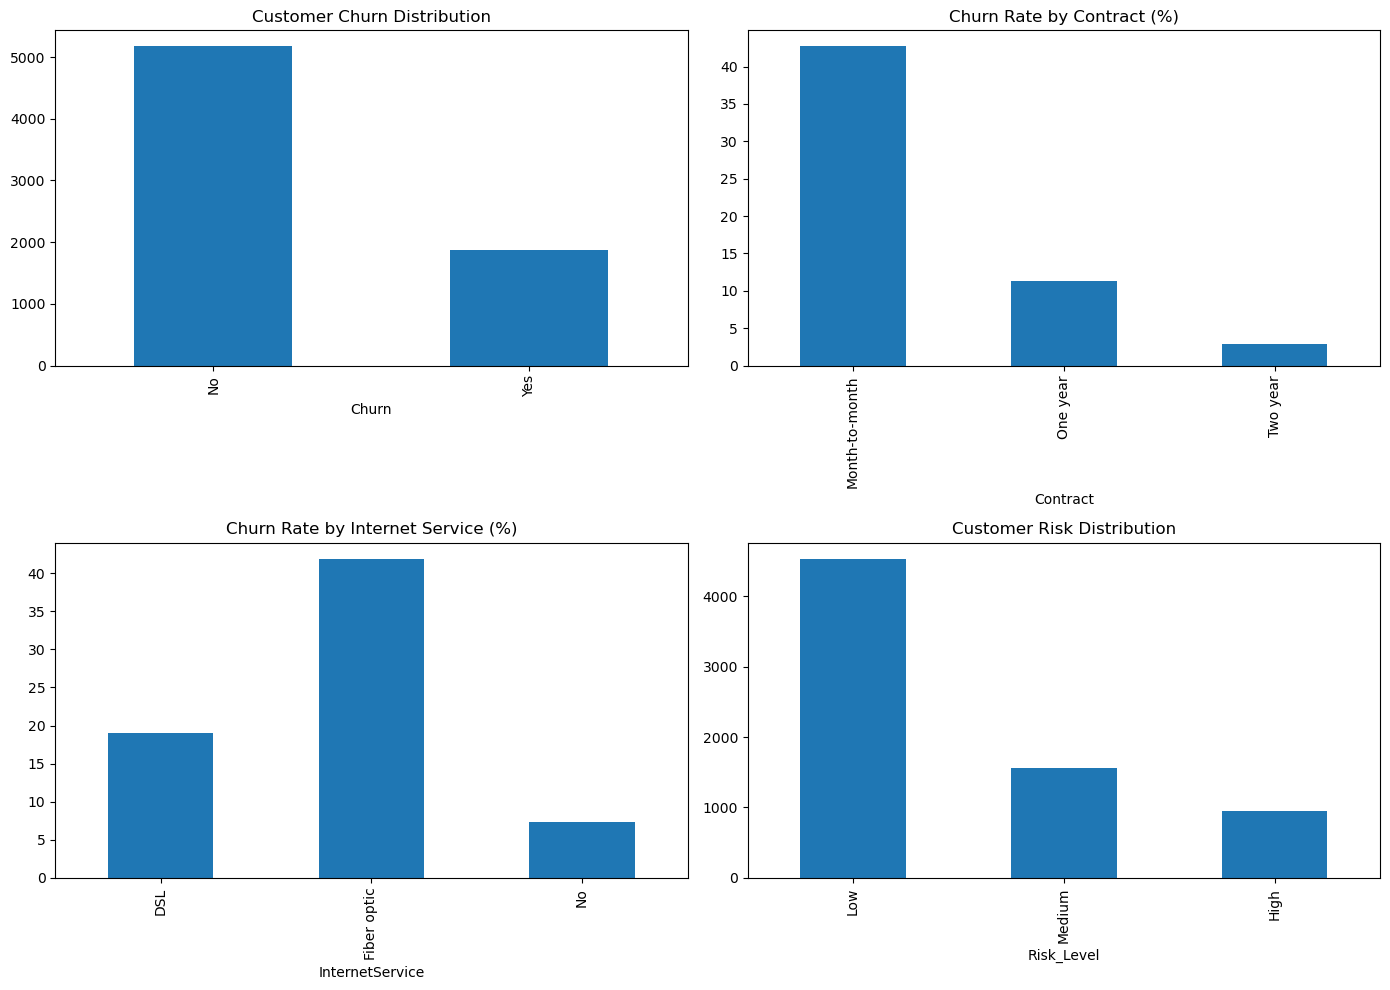

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["Churn"].value_counts().plot(
    kind="bar",
    ax=axes[0, 0],
    title="Customer Churn Distribution")

df.groupby("Contract")["Churn_Encoded"].mean().mul(100).plot(
    kind="bar",
    ax=axes[0, 1],
    title="Churn Rate by Contract (%)")

df.groupby("InternetService")["Churn_Encoded"].mean().mul(100).plot(
    kind="bar",
    ax=axes[1, 0],
    title="Churn Rate by Internet Service (%)")

df["Risk_Level"].value_counts().reindex(
    ["Low", "Medium", "High"]).plot(
    kind="bar",
    ax=axes[1, 1],
    title="Customer Risk Distribution")

plt.tight_layout()
plt.show()

In [37]:
high_risk_report = df[
    df["Risk_Level"] == "High"
][["customerID",
    "Contract",
    "InternetService",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Probability",
    "Risk_Level",
    "Recommended_Action"]].sort_values(
    "Churn_Probability",ascending=False)
    

high_risk_report.to_csv(
    "data/processed/high_risk_customers.csv",
    index=False)

print("High-risk customer report created successfully!")
print("High-risk customers:", len(high_risk_report))
print("Saved to: data/processed/high_risk_customers.csv")

High-risk customer report created successfully!
High-risk customers: 949
Saved to: data/processed/high_risk_customers.csv


In [39]:
!pip install streamlit

   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/10.5 MB 9.4 MB/s eta 0:00:01
   ------------------ --------------------- 5.0/10.5 MB 13.8 MB/s eta 0:00:01
   ---------------------- ----------------- 6.0/10.5 MB 10.9 MB/s eta 0:00:01
   --------------------------- ------------ 7.3/10.5 MB 9.4 MB/s eta 0:00:01
   --------------------------------- ------ 8.9/10.5 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 9.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   ---------------------------------------- 797.6/797.6 kB 8.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ----------- ---------------------------- 3.4/11.4 MB 15.5 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.4 MB 14.9 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.4 MB 12.5 MB/s eta 0:00:01
   -------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 1.23.4 requires anyio<4,>=3.1.0, but you have anyio 4.14.2 which is incompatible.
tensorflow-intel 2.13.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.36.1 which is incompatible.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.12.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import streamlit

print("Streamlit version:", streamlit.__version__)
print("Streamlit is ready!")

Streamlit version: 1.62.0
Streamlit is ready!


In [41]:
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="AI Business Intelligence Platform",
    page_icon="📊",
    layout="wide")

DATA_PATH = "data/processed/business_intelligence_data.csv"
MODEL_PATH = "models/churn_prediction_model.pkl"

df = pd.read_csv(DATA_PATH)
model = joblib.load(MODEL_PATH)

st.title("AI-Powered Business Intelligence & Decision Support Platform")
st.caption("Customer Analytics • Churn Prediction • Risk Intelligence • Decision Support")

st.divider()

total_customers = df["customerID"].nunique()
churned_customers = (df["Churn"] == "Yes").sum()
churn_rate = df["Churn_Encoded"].mean() * 100
total_revenue = df["TotalCharges"].sum()
high_risk_customers = (df["Risk_Level"] == "High").sum()

col1, col2, col3, col4, col5 = st.columns(5)

col1.metric("Total Customers", f"{total_customers:,}")
col2.metric("Churned Customers", f"{churned_customers:,}")
col3.metric("Churn Rate", f"{churn_rate:.2f}%")
col4.metric("Total Revenue", f"${total_revenue:,.0f}")
col5.metric("High Risk Customers", f"{high_risk_customers:,}")

st.divider()

st.subheader("Business Overview")

col1, col2 = st.columns(2)

with col1:
    st.write("### Churn by Contract")

    contract_churn = (
        df.groupby("Contract")["Churn_Encoded"]
        .mean()
        .mul(100)
        .round(2))

    st.bar_chart(contract_churn)

with col2:
    st.write("### Churn by Internet Service")

    internet_churn = (
        df.groupby("InternetService")["Churn_Encoded"]
        .mean()
        .mul(100)
        .round(2))

    st.bar_chart(internet_churn)

st.divider()

st.subheader("Customer Risk Distribution")

risk_distribution = (
    df["Risk_Level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .fillna(0))

st.bar_chart(risk_distribution)

st.divider()

st.subheader("High-Risk Customers")

high_risk = (
    df[df["Risk_Level"] == "High"]
    [ ["customerID",
            "Contract",
            "InternetService",
            "tenure",
            "MonthlyCharges",
            "Churn_Probability",
            "Recommended_Action"]].sort_values("Churn_Probability", ascending=False))
            
st.dataframe(
    high_risk.head(50),
    use_container_width=True)

st.divider()

st.caption("AI Business Intelligence Platform | Decision Support System")

2026-09-01 22:11:11.040 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 22:11:11.306 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 22:11:11.627 
  command:

    streamlit run C:\Users\HP\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-01 22:11:11.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 22:11:11.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 22:11:11.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-01 22:11:11.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running

DeltaGenerator()

In [42]:
print("Current folder:")
print(os.getcwd())

print("\nProject files:")
print(os.listdir())

Current folder:
C:\Users\HP

Project files:
['.astropy', '.bash_history', '.cache', '.conda', '.condarc', '.copilot', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.labelImgSettings.pkl', '.matplotlib', '.ms-ad', '.spyder-py3', '.vscode', '.vscode-shared', '01_customer_intelligence.ipynb', '2 mar', '2 mar .ipynb', '2 mar.ipynb', '22nd july ai.ipynb', 'Air Temperature Time Series Project.ipynb', 'anaconda3', 'AppData', 'Application Data', 'Arrays.ipynb', 'Campusx', 'chatbot', 'cleaned_dataset.csv', 'Contacts', 'Cookies', 'data', 'Documents', 'Employee_Performance_Analysis.ipynb', 'Favorites', 'Gender_Detection_1001_Project.ipynb', 'Hypothesis_Testing_parametric.ipynb', 'Image_Classification with 10 categories..ipynb', 'Kaggle_API.ipynb', 'Links', 'Local Settings', 'Measure_of_central_tendencies_and_data_variability (1).ipynb', 'models', 'Music', 'My Documents', 'nbformat..ipynb', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{32cd8d16

In [43]:
project_path = r"D:\Downloads\AI_Business_Intelligence_Platform"

os.chdir(project_path)

print("Project directory set successfully!")
print("Current folder:", os.getcwd())

Project directory set successfully!
Current folder: D:\Downloads\AI_Business_Intelligence_Platform


In [44]:
import os

print("Project Structure:")
print()

for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    for file in files:
        print(f"{indent}    {file}")

Project Structure:

./
    data/
        Telco-Customer-Churn.csv


In [45]:
import os

os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Project folders created successfully!")

print("\nFolders:")
print("data/")
print("data/processed/")
print("models/")

Project folders created successfully!

Folders:
data/
data/processed/
models/


In [46]:
df.to_csv("data/processed/business_intelligence_data.csv", index=False)

high_risk_report = df[df["Risk_Level"] == "High"][[
    "customerID",
    "Contract",
    "InternetService",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Probability",
    "Risk_Level",
    "Recommended_Action"]].sort_values("Churn_Probability", ascending=False)

high_risk_report.to_csv(
    "data/processed/high_risk_customers.csv",
    index=False)

joblib.dump(
    model,
    "models/churn_prediction_model.pkl")

print("All project files saved successfully!")
print("Business data:", os.path.exists("data/processed/business_intelligence_data.csv"))
print("High-risk report:", os.path.exists("data/processed/high_risk_customers.csv"))
print("ML model:", os.path.exists("models/churn_prediction_model.pkl"))

All project files saved successfully!
Business data: True
High-risk report: True
ML model: True
